# Iris 데이터 분류

붓꽃(Iris) 데이터셋에 여러 분류 모델(KNN, Gaussian Naive Bayes, Decision Tree, AdaBoost)을 적용하고,
정확도와 새로운 샘플에 대한 예측 결과를 비교하는 실습.

- **Dataset**: `sklearn.datasets.load_iris` — 샘플 150개, 특징 4개(꽃받침 길이/너비, 꽃잎 길이/너비), 클래스 3개(setosa / versicolor / virginica)
- **다루는 내용**: 모델 학습 및 정확도 비교, KNN의 `n_neighbors` 하이퍼파라미터 튜닝, 새로운 데이터에 대한 예측


## 1. 데이터 로드
`sklearn`에 내장된 Iris 데이터셋을 불러온다.

In [1]:
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np

iris = datasets.load_iris()
X = iris.data
y = iris.target

print("샘플 수:", X.shape[0])
print("특징 수:", X.shape[1])
print("클래스:", ", ".join(str(c) for c in iris.target_names))


샘플 수: 150
특징 수: 4
클래스: setosa, versicolor, virginica


## 2. 데이터 시각화
4개 특징 중 앞의 2개(sepal length, sepal width)만 뽑아 2차원 산점도로 그려본다. 이 두 특징만으로도 클래스가 어느 정도 구분되는지 눈으로 확인하기 위한 단계이며, 나머지 2개 특징(꽃잎 길이/너비)은 시각화에는 포함되지 않는다.

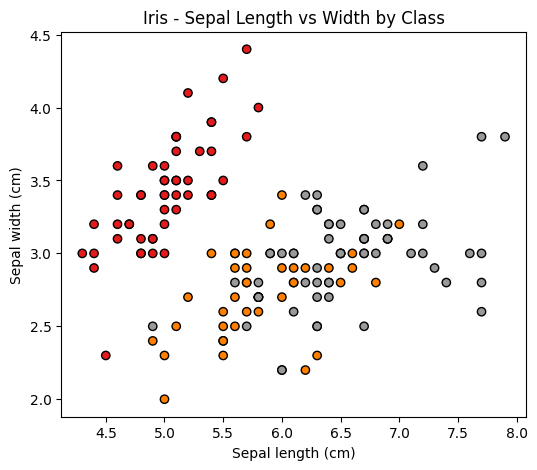

In [2]:
X_visual = X[:, :2]  # sepal length, sepal width

plt.figure(figsize=(6, 5))
plt.scatter(X_visual[:, 0], X_visual[:, 1], c=y, cmap=plt.cm.Set1, edgecolor='k')
plt.xlabel('Sepal length (cm)')
plt.ylabel('Sepal width (cm)')
plt.title('Iris - Sepal Length vs Width by Class')
plt.show()


## 3. Train / Test 분할
전체 데이터를 80:20으로 분할한다. `random_state`를 고정해서 실행할 때마다 같은 방식으로 나뉘도록 한다.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)
print("Train:", X_train.shape, " Test:", X_test.shape)


Train: (120, 4)  Test: (30, 4)


## 4. 모델 학습 및 정확도 비교

같은 train/test 데이터로 4가지 모델을 각각 학습시키고 정확도를 비교한다.

- **KNN**: 가장 가까운 이웃 K개의 다수결로 클래스를 정한다 (K=6)
- **Gaussian Naive Bayes**: 각 특징이 정규분포를 따른다고 가정하고 확률적으로 분류한다
- **Decision Tree**: 특징 값 기준으로 데이터를 분기해 나가며 분류한다
- **AdaBoost**: 여러 개의 약한 분류기를 순차적으로 결합하는 앙상블 기법이다

(Decision Tree, AdaBoost는 내부적으로 무작위 요소가 있어, 결과 재현을 위해 `random_state`를 고정했다.)

In [4]:
def evaluate_model(model, name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name:15s} accuracy = {acc:.4f}")
    return acc

models = {
    "KNN (k=6)": KNeighborsClassifier(n_neighbors=6),
    "GaussianNB": GaussianNB(),
    "DecisionTree": DecisionTreeClassifier(random_state=4),
    "AdaBoost": AdaBoostClassifier(random_state=4),
}

results = {name: evaluate_model(model, name) for name, model in models.items()}


KNN (k=6)       accuracy = 0.9667
GaussianNB      accuracy = 0.9667
DecisionTree    accuracy = 0.9667
AdaBoost        accuracy = 0.9333


## 5. KNN 하이퍼파라미터(`n_neighbors`) 튜닝

KNN의 `n_neighbors` 값을 1~14까지 바꿔가며 train accuracy와 test accuracy를 각각 측정하고 그래프로 비교한다.
K가 너무 작으면(예: 1) train accuracy는 매우 높지만 test accuracy는 상대적으로 낮아지는 **과적합** 경향이 나타나는지 확인하는 실험이다.

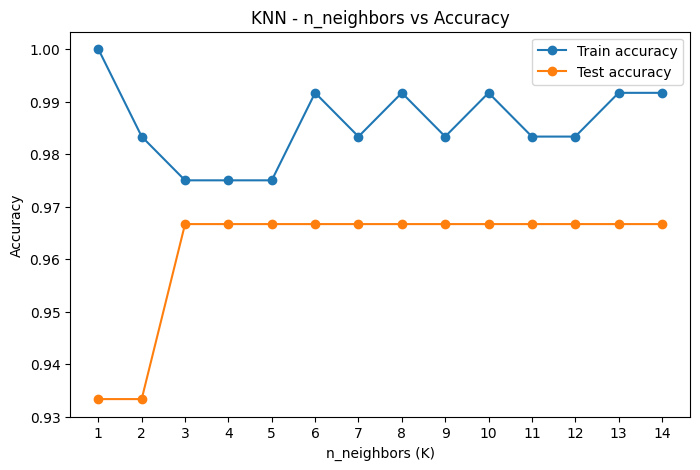

In [5]:
train_acc, test_acc = [], []
neighbor_range = range(1, 15)

for n in neighbor_range:
    clf = KNeighborsClassifier(n_neighbors=n)
    clf.fit(X_train, y_train)
    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

plt.figure(figsize=(8, 5))
plt.plot(neighbor_range, train_acc, marker='o', label='Train accuracy')
plt.plot(neighbor_range, test_acc, marker='o', label='Test accuracy')
plt.xlabel('n_neighbors (K)')
plt.ylabel('Accuracy')
plt.title('KNN - n_neighbors vs Accuracy')
plt.xticks(list(neighbor_range))
plt.legend()
plt.show()


## 6. 새로운 데이터 예측
학습에 사용하지 않은 임의의 샘플 2개를 넣어, 4개 모델이 각각 어떤 클래스로 예측하는지 비교한다.

In [6]:
x_new = [[3, 4, 5, 2], [5, 4, 2, 2]]
class_names = {0: 'setosa', 1: 'versicolor', 2: 'virginica'}

print("새로운 샘플에 대한 모델별 예측 결과")
for name, model in models.items():
    pred = model.predict(x_new)
    labels = [class_names[p] for p in pred]
    print(f"{name:15s} -> {labels}")


새로운 샘플에 대한 모델별 예측 결과
KNN (k=6)       -> ['versicolor', 'setosa']
GaussianNB      -> ['virginica', 'versicolor']
DecisionTree    -> ['virginica', 'setosa']
AdaBoost        -> ['virginica', 'versicolor']


## 결과 및 배운 점

- 이번 데이터 분할 기준으로 4개 모델 모두 정확도 0.9667로 동일하게 나왔다. Iris는 비교적 클래스 간 구분이
  뚜렷한 데이터셋이라 어떤 분류 모델을 쓰든 전체 정확도 차이가 크지 않았다.
- **정확도가 같아도 개별 샘플에 대한 예측은 모델마다 달라질 수 있다** — 새 샘플 2개 중 하나(`[5,4,2,2]`)에 대해
  KNN·GaussianNB·AdaBoost는 `versicolor`로 예측했지만 DecisionTree만 `setosa`로 다르게 예측했다.
  또한 KNN은 첫 번째 샘플(`[3,4,5,2]`)도 나머지 세 모델과 다르게 `versicolor`로 예측했다.
  → 전체 정확도만으로는 드러나지 않는, 모델별 판단 기준의 차이를 확인할 수 있었다.
- KNN은 K=1일 때 train accuracy가 100%까지 올라가지만 test accuracy는 오히려 떨어지는(0.933) 과적합 패턴이 보였고,
  K≥3부터는 test accuracy가 0.967로 안정됐다.
- 같은 데이터셋이라도 어떤 모델을 쓰느냐에 따라 정확도뿐 아니라 개별 예측 성향까지 달라진다는 것을 직접 비교하며 확인할 수 있었다.
